<a href="https://colab.research.google.com/github/jumafernandez/generacion_prompts/blob/main/semana6/VannaAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install vanna --quiet

In [ ]:
from google.colab import drive
import os
import pandas as pd
import sqlite3

drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [ ]:
%cd '/content/gdrive/MyDrive/Coderhouse/IA: Generación de Prompts/💻 Semana 6: Aplicaciones avanzadas del prompt'

/content/gdrive/MyDrive/Coderhouse/IA: Generación de Prompts/💻 Semana 6: Aplicaciones avanzadas del prompt


In [ ]:
import vanna as vn
from vanna.remote import VannaDefault

# Ejemplo: 4099cb83d21f498f8e627801737b64ac
vn = VannaDefault(model='coderhouse', api_key='')

In [ ]:
# Conectar a la base de datos SQLite
db_path = "nba_salary.sqlite"  # Reemplaza con la ruta correcta a tu BD
vn.connect_to_sqlite(db_path)

In [ ]:
df_ddl = vn.run_sql("SELECT type, sql FROM sqlite_master WHERE sql is not null")

for ddl in df_ddl['sql'].to_list():
  vn.train(ddl=ddl)

Adding ddl: CREATE TABLE `NBA_season1718_salary` (
  `X1` REAL,
  `Player` TEXT,
  `Tm` TEXT,
  `season17_18` REAL
)
Adding ddl: CREATE TABLE `Seasons_Stats` (
  `X1` REAL,
  `Year` REAL,
  `Player` TEXT,
  `Pos` TEXT,
  `Age` REAL,
  `Tm` TEXT,
  `G` REAL,
  `GS` INTEGER,
  `MP` REAL,
  `PER` REAL,
  `TS%` REAL,
  `3PAr` INTEGER,
  `FTr` REAL,
  `ORB%` INTEGER,
  `DRB%` INTEGER,
  `TRB%` INTEGER,
  `AST%` INTEGER,
  `STL%` INTEGER,
  `BLK%` INTEGER,
  `TOV%` INTEGER,
  `USG%` INTEGER,
  `blanl` INTEGER,
  `OWS` REAL,
  `DWS` REAL,
  `WS` REAL,
  `WS/48` REAL,
  `blank2` INTEGER,
  `OBPM` INTEGER,
  `DBPM` INTEGER,
  `BPM` INTEGER,
  `VORP` INTEGER,
  `FG` REAL,
  `FGA` REAL,
  `FG%` REAL,
  `3P` INTEGER,
  `3PA` INTEGER,
  `3P%` INTEGER,
  `2P` REAL,
  `2PA` REAL,
  `2P%` REAL,
  `eFG%` REAL,
  `FT` REAL,
  `FTA` REAL,
  `FT%` REAL,
  `ORB` INTEGER,
  `DRB` INTEGER,
  `TRB` REAL,
  `AST` REAL,
  `STL` INTEGER,
  `BLK` INTEGER,
  `TOV` INTEGER,
  `PF` REAL,
  `PTS` REAL
)


In [ ]:
# At any time you can inspect what training data the package is able to reference
training_data = vn.get_training_data()
training_data

,id,training_data_type,question,content
0,501300-ddl,ddl,None,CREATE TABLE `NBA_season1718_salary` (\n `X1`...
1,501303-ddl,ddl,None,"CREATE TABLE `Seasons_Stats` (\n `X1` REAL,\n..."
2,501302-ddl,ddl,None,CREATE TABLE `NBA_season1718_salary` (\n `X1`...
3,956085-sql,sql,Obtener los jugadores con mayor salario,"SELECT Player, season17_18 \nFROM NBA_season17..."
4,501304-ddl,ddl,None,CREATE TABLE `NBA_season1718_salary` (\n `X1`...
5,501301-ddl,ddl,None,"CREATE TABLE `Seasons_Stats` (\n `X1` REAL,\n..."
6,501305-ddl,ddl,None,"CREATE TABLE `Seasons_Stats` (\n `X1` REAL,\n..."


In [ ]:
query = "Obtener los jugadores con mayor salario"

In [ ]:
# Generar consulta SQL desde lenguaje natural
consulta_sql = vn.generate_sql(query)
print("Consulta generada:", consulta_sql)

SQL Prompt: [{'role': 'system', 'content': "You are a SQLite expert. Please help to generate a SQL query to answer the question. Your response should ONLY be based on the given context and follow the response guidelines and format instructions. \n===Tables \nCREATE TABLE `NBA_season1718_salary` (\n  `X1` REAL,\n  `Player` TEXT,\n  `Tm` TEXT,\n  `season17_18` REAL\n)\n\nCREATE TABLE `NBA_season1718_salary` (\n  `X1` REAL,\n  `Player` TEXT,\n  `Tm` TEXT,\n  `season17_18` REAL\n)\n\nCREATE TABLE `NBA_season1718_salary` (\n  `X1` REAL,\n  `Player` TEXT,\n  `Tm` TEXT,\n  `season17_18` REAL\n)\n\nCREATE TABLE `Seasons_Stats` (\n  `X1` REAL,\n  `Year` REAL,\n  `Player` TEXT,\n  `Pos` TEXT,\n  `Age` REAL,\n  `Tm` TEXT,\n  `G` REAL,\n  `GS` INTEGER,\n  `MP` REAL,\n  `PER` REAL,\n  `TS%` REAL,\n  `3PAr` INTEGER,\n  `FTr` REAL,\n  `ORB%` INTEGER,\n  `DRB%` INTEGER,\n  `TRB%` INTEGER,\n  `AST%` INTEGER,\n  `STL%` INTEGER,\n  `BLK%` INTEGER,\n  `TOV%` INTEGER,\n  `USG%` INTEGER,\n  `blanl` INTEGER,

In [ ]:
respuesta = vn.ask(question=query,
                   print_results=False)

SQL Prompt: [{'role': 'system', 'content': "You are a SQLite expert. Please help to generate a SQL query to answer the question. Your response should ONLY be based on the given context and follow the response guidelines and format instructions. \n===Tables \nCREATE TABLE `NBA_season1718_salary` (\n  `X1` REAL,\n  `Player` TEXT,\n  `Tm` TEXT,\n  `season17_18` REAL\n)\n\nCREATE TABLE `NBA_season1718_salary` (\n  `X1` REAL,\n  `Player` TEXT,\n  `Tm` TEXT,\n  `season17_18` REAL\n)\n\nCREATE TABLE `NBA_season1718_salary` (\n  `X1` REAL,\n  `Player` TEXT,\n  `Tm` TEXT,\n  `season17_18` REAL\n)\n\nCREATE TABLE `Seasons_Stats` (\n  `X1` REAL,\n  `Year` REAL,\n  `Player` TEXT,\n  `Pos` TEXT,\n  `Age` REAL,\n  `Tm` TEXT,\n  `G` REAL,\n  `GS` INTEGER,\n  `MP` REAL,\n  `PER` REAL,\n  `TS%` REAL,\n  `3PAr` INTEGER,\n  `FTr` REAL,\n  `ORB%` INTEGER,\n  `DRB%` INTEGER,\n  `TRB%` INTEGER,\n  `AST%` INTEGER,\n  `STL%` INTEGER,\n  `BLK%` INTEGER,\n  `TOV%` INTEGER,\n  `USG%` INTEGER,\n  `blanl` INTEGER,

In [ ]:
print(respuesta[0])

SELECT Player, season17_18 
FROM NBA_season1718_salary 
ORDER BY season17_18 DESC 
LIMIT 10;


In [ ]:
print(respuesta[1])

              Player  season17_18
0      Stephen Curry   34682550.0
1       LeBron James   33285709.0
2       Paul Millsap   31269231.0
3     Gordon Hayward   29727900.0
4      Blake Griffin   29512900.0
5         Kyle Lowry   28703704.0
6  Russell Westbrook   28530608.0
7        Mike Conley   28530608.0
8       James Harden   28299399.0
9      DeMar DeRozan   27739975.0


In [ ]:
print(respuesta[2])

Figure({
    'data': [{'alignmentgroup': 'True',
              'hovertemplate': 'Player=%{x}<br>season17_18=%{y}<extra></extra>',
              'legendgroup': '',
              'marker': {'color': '#636efa', 'pattern': {'shape': ''}},
              'name': '',
              'offsetgroup': '',
              'orientation': 'v',
              'showlegend': False,
              'textposition': 'auto',
              'type': 'bar',
              'x': array(['Stephen Curry', 'LeBron James', 'Paul Millsap', 'Gordon Hayward',
                          'Blake Griffin', 'Kyle Lowry', 'Russell Westbrook', 'Mike Conley',
                          'James Harden', 'DeMar DeRozan'], dtype=object),
              'xaxis': 'x',
              'y': array([34682550., 33285709., 31269231., 29727900., 29512900., 28703704.,
                          28530608., 28530608., 28299399., 27739975.]),
              'yaxis': 'y'}],
    'layout': {'barmode': 'relative',
               'legend': {'tracegroupgap': 0},
  

In [ ]:
import plotly.graph_objects as go

grafico = respuesta[2]  # Guardar el gráfico
grafico.show()  # Mostrar el gráfico en una ventana interactiva

In [ ]:
from vanna.flask import VannaFlaskApp

#app = VannaFlaskApp(vn)
#app.run()

SQL Prompt: [{'role': 'system', 'content': "You are a SQLite expert. Please help to generate a SQL query to answer the question. Your response should ONLY be based on the given context and follow the response guidelines and format instructions. \n===Tables \nCREATE TABLE `NBA_season1718_salary` (\n  `X1` REAL,\n  `Player` TEXT,\n  `Tm` TEXT,\n  `season17_18` REAL\n)\n\nCREATE TABLE `NBA_season1718_salary` (\n  `X1` REAL,\n  `Player` TEXT,\n  `Tm` TEXT,\n  `season17_18` REAL\n)\n\nCREATE TABLE `NBA_season1718_salary` (\n  `X1` REAL,\n  `Player` TEXT,\n  `Tm` TEXT,\n  `season17_18` REAL\n)\n\nCREATE TABLE `Seasons_Stats` (\n  `X1` REAL,\n  `Year` REAL,\n  `Player` TEXT,\n  `Pos` TEXT,\n  `Age` REAL,\n  `Tm` TEXT,\n  `G` REAL,\n  `GS` INTEGER,\n  `MP` REAL,\n  `PER` REAL,\n  `TS%` REAL,\n  `3PAr` INTEGER,\n  `FTr` REAL,\n  `ORB%` INTEGER,\n  `DRB%` INTEGER,\n  `TRB%` INTEGER,\n  `AST%` INTEGER,\n  `STL%` INTEGER,\n  `BLK%` INTEGER,\n  `TOV%` INTEGER,\n  `USG%` INTEGER,\n  `blanl` INTEGER,

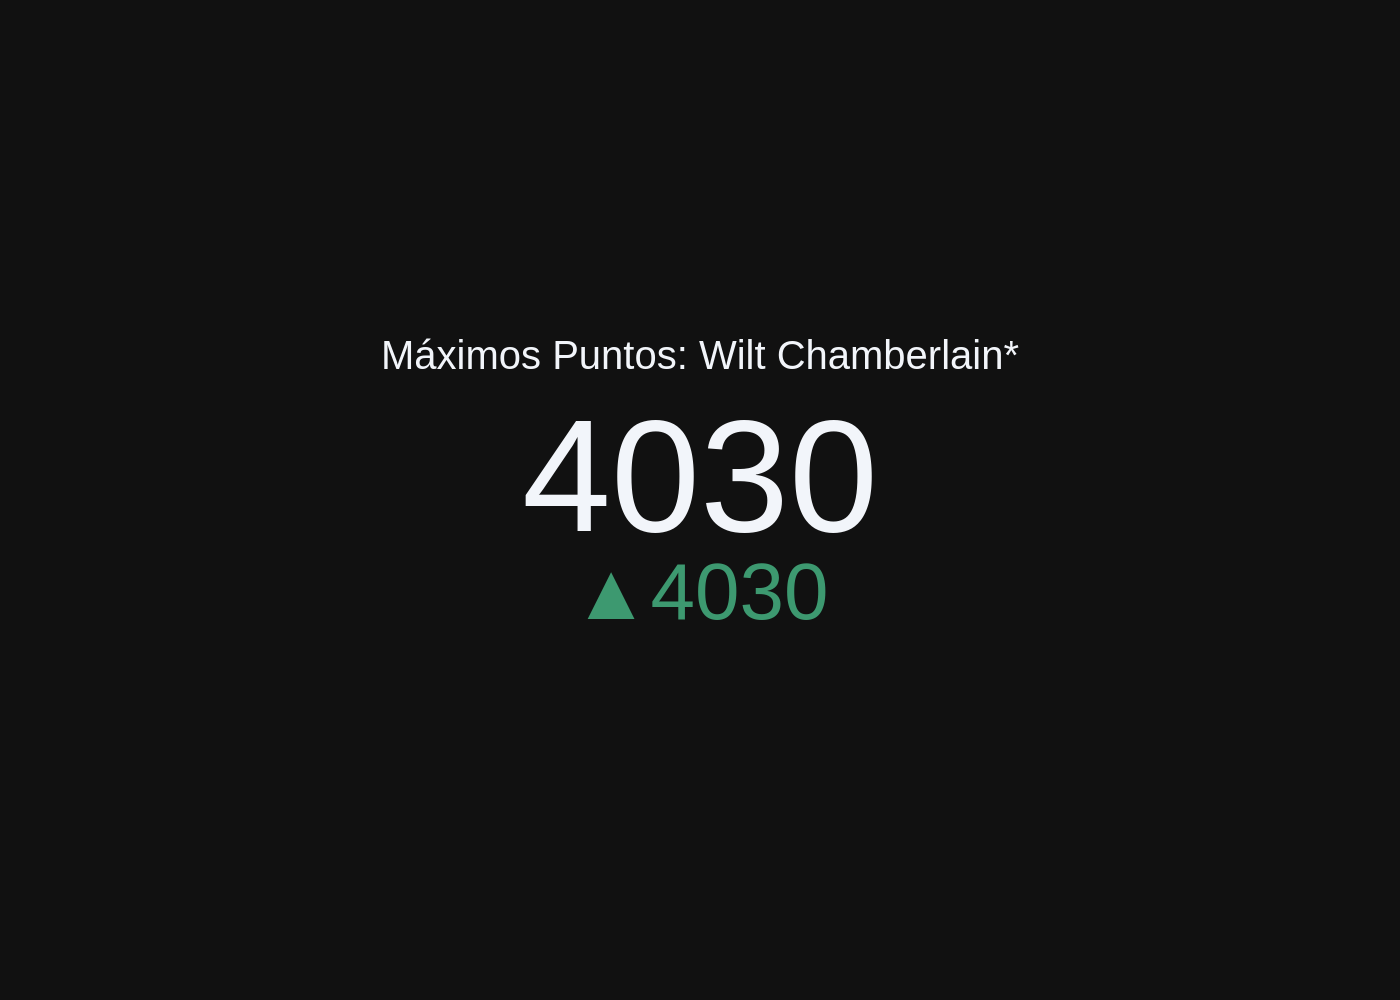

In [ ]:
query = "¿Cuál es el jugador que más puntos y asistencias registró?"

respuesta = vn.ask(question=query,
                   allow_llm_to_see_data=True)

SQL Prompt: [{'role': 'system', 'content': "You are a SQLite expert. Please help to generate a SQL query to answer the question. Your response should ONLY be based on the given context and follow the response guidelines and format instructions. \n===Tables \nCREATE TABLE `NBA_season1718_salary` (\n  `X1` REAL,\n  `Player` TEXT,\n  `Tm` TEXT,\n  `season17_18` REAL\n)\n\nCREATE TABLE `NBA_season1718_salary` (\n  `X1` REAL,\n  `Player` TEXT,\n  `Tm` TEXT,\n  `season17_18` REAL\n)\n\nCREATE TABLE `NBA_season1718_salary` (\n  `X1` REAL,\n  `Player` TEXT,\n  `Tm` TEXT,\n  `season17_18` REAL\n)\n\nCREATE TABLE `Seasons_Stats` (\n  `X1` REAL,\n  `Year` REAL,\n  `Player` TEXT,\n  `Pos` TEXT,\n  `Age` REAL,\n  `Tm` TEXT,\n  `G` REAL,\n  `GS` INTEGER,\n  `MP` REAL,\n  `PER` REAL,\n  `TS%` REAL,\n  `3PAr` INTEGER,\n  `FTr` REAL,\n  `ORB%` INTEGER,\n  `DRB%` INTEGER,\n  `TRB%` INTEGER,\n  `AST%` INTEGER,\n  `STL%` INTEGER,\n  `BLK%` INTEGER,\n  `TOV%` INTEGER,\n  `USG%` INTEGER,\n  `blanl` INTEGER,

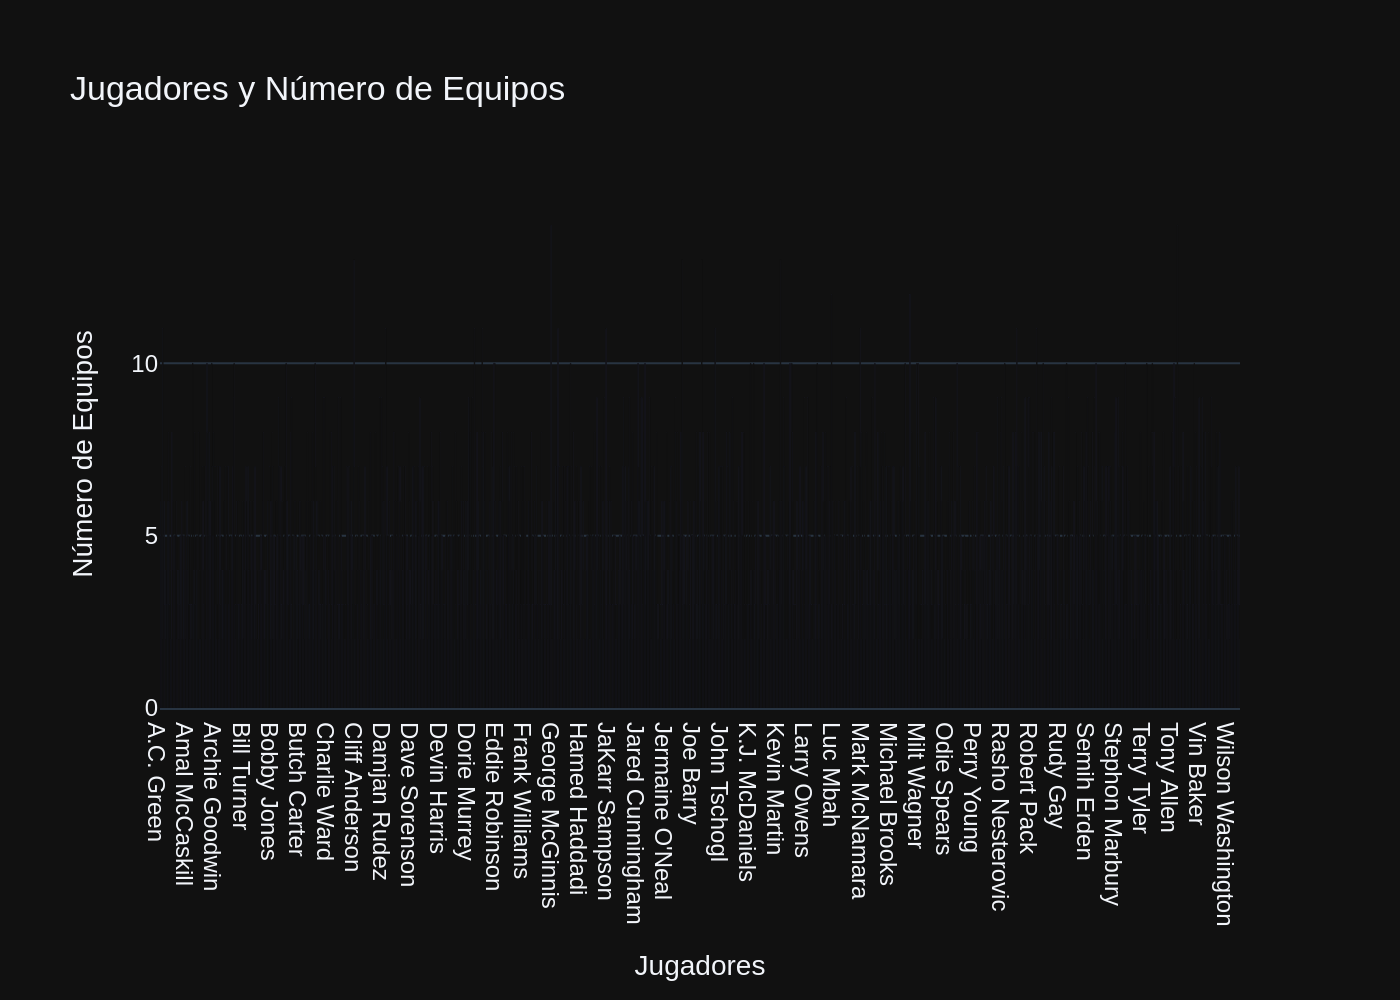

In [ ]:
query = "¿Cuáles son los jugadores que estuvieron en más de un equipo y en cuantos equipos estuvieron?"

respuesta = vn.ask(question=query,
                   allow_llm_to_see_data=True)

SQL Prompt: [{'role': 'system', 'content': "You are a SQLite expert. Please help to generate a SQL query to answer the question. Your response should ONLY be based on the given context and follow the response guidelines and format instructions. \n===Tables \nCREATE TABLE `Seasons_Stats` (\n  `X1` REAL,\n  `Year` REAL,\n  `Player` TEXT,\n  `Pos` TEXT,\n  `Age` REAL,\n  `Tm` TEXT,\n  `G` REAL,\n  `GS` INTEGER,\n  `MP` REAL,\n  `PER` REAL,\n  `TS%` REAL,\n  `3PAr` INTEGER,\n  `FTr` REAL,\n  `ORB%` INTEGER,\n  `DRB%` INTEGER,\n  `TRB%` INTEGER,\n  `AST%` INTEGER,\n  `STL%` INTEGER,\n  `BLK%` INTEGER,\n  `TOV%` INTEGER,\n  `USG%` INTEGER,\n  `blanl` INTEGER,\n  `OWS` REAL,\n  `DWS` REAL,\n  `WS` REAL,\n  `WS/48` REAL,\n  `blank2` INTEGER,\n  `OBPM` INTEGER,\n  `DBPM` INTEGER,\n  `BPM` INTEGER,\n  `VORP` INTEGER,\n  `FG` REAL,\n  `FGA` REAL,\n  `FG%` REAL,\n  `3P` INTEGER,\n  `3PA` INTEGER,\n  `3P%` INTEGER,\n  `2P` REAL,\n  `2PA` REAL,\n  `2P%` REAL,\n  `eFG%` REAL,\n  `FT` REAL,\n  `FTA` R

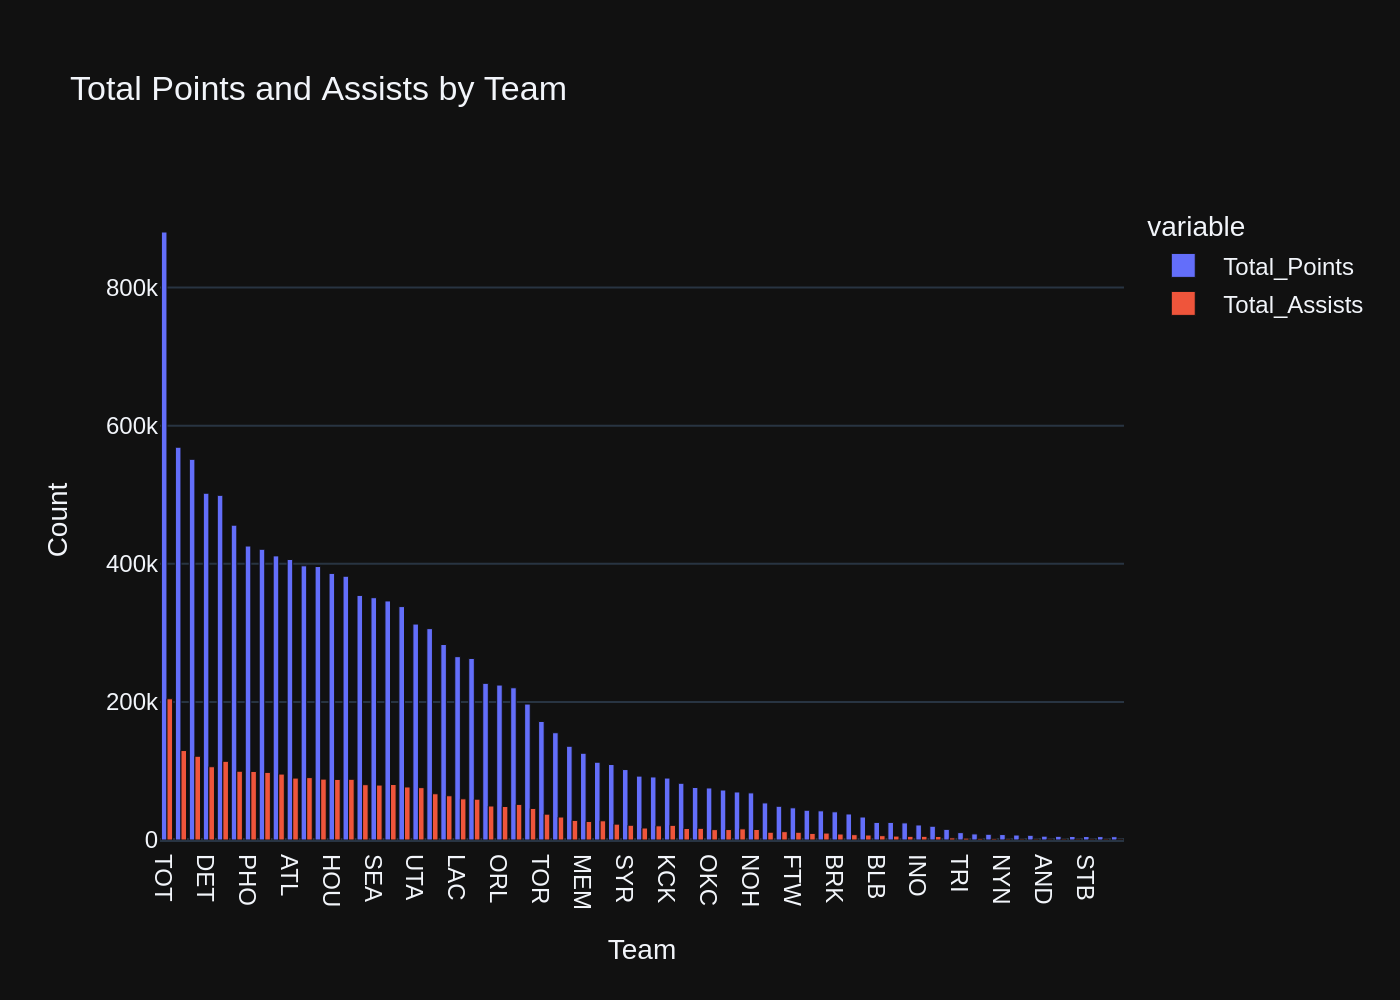

In [ ]:
query = "¿Qué equipos registraron más puntos y asistencias?"

respuesta = vn.ask(question=query,
                   allow_llm_to_see_data=True)